## Performance comparison of triangular matrix inverse

> The goal is to understand the "peak performance" of Ascend for AIV / AIC triangular inverse methods.

<Figure size 640x480 with 0 Axes>

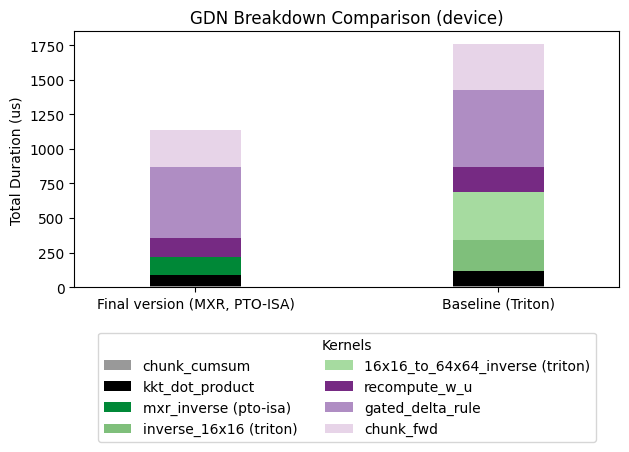

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_clean(path):
    df = pd.read_csv(path)

    # Clean Start Time column (fix quotes)
    df["Start Time(us)"] = (
        df["Start Time(us)"]
        .astype(str)
        .str.replace('"', '', regex=False)
        .astype(float)
    )
    return df

palette = [### Colorbrewer colors
    "#999999",
    "black",
    "#008837",
    "#7fbf7b",
    "#a6dba0",
    "#762a83",
    "#af8dc3",
    "#e7d4e8"]

# Load both files
df1 = load_and_clean("/home/ggottardo/gdn-tri-inverse/pto-isa_kernel_details.csv")
df2 = load_and_clean("/home/ggottardo/gdn-tri-inverse/triton_kernel_details.csv")

# ---- Select operations ----
selected_names = [
    "chunk_cumsum",
    "kkt_dot_product",
    "mxr_inverse (pto-isa)",
    "inverse_16x16 (triton)",
    "16x16_to_64x64_inverse (triton)",
    "recompute_w_u",
    "gated_delta_rule",
    "chunk_fwd",
]


# Filter + aggregate
def get_breakdown(df):
    return (
        df[df["Name"].isin(selected_names)]
        .groupby("Name")["Duration(us)"]
        .sum()
    )

b1 = get_breakdown(df1)
b2 = get_breakdown(df2)

# Combine into one table
combined = pd.DataFrame({
    "Final version (MXR, PTO-ISA)": b1,
    "Baseline (Triton)": b2
}).fillna(0).reindex(selected_names)  # Ensure consistent order

# ---- Plot stacked bar ----
plt.figure()
combined.T.plot(kind="bar", stacked=True, color=palette, width=0.3)

plt.ylabel("Total Duration (us)")
plt.title("GDN Breakdown Comparison (device)")

plt.xticks(rotation=0)
plt.legend(
    title="Kernels",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2  # adjust based on number of ops
)
plt.tight_layout()
plt.savefig("figs/gdn_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()